In [ ]:
import os
import sys
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.transform import resize
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.layers import RandomFlip, RandomRotation
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam, SGD, RMSprop, Nadam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
import random
import math
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_recall_fscore_support

In [60]:
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)  # Prima dell'avvio TF
np.random.seed(SEED)
random.seed(SEED)
tf.config.experimental.enable_op_determinism()  # ← questa è la chiave
tf.random.set_seed(SEED)

In [61]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Selezioniamo solo la GPU:0 (la tua RTX 4060)
        tf.config.set_visible_devices(gpus[0], 'GPU')
        # Configurazione opzionale per gestire la memoria (evita crash se la memoria finisce)
        tf.config.experimental.set_memory_growth(gpus[0], True)
        print(f"✅ Training bloccato sulla GPU dedicata: {gpus[0].name}")
    except RuntimeError as e:
        print(f"⚠️ Errore durante l'impostazione della GPU: {e}")

✅ Training bloccato sulla GPU dedicata: /physical_device:GPU:0


In [62]:
df = pd.read_pickle("../project/Dataset.pkl")
df.head()

,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],[[none]]
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],[[none]]


In [63]:
def clean_nested_columns(df):
    # Rename the column with the original typo
    if 'trianTestLabel' in df.columns:
        df.rename(columns={'trianTestLabel': 'trainTestLabel'}, inplace=True)
    
    # Inner function to extract and format text
    def extract_text(value):
        while isinstance(value, (np.ndarray, list)):
            if len(value) == 0:
                return "unknown"
            value = value[0]
        
        # Return the clean string in lowercase (e.g., 'none', 'training', 'center')
        return str(value).lower()
    
    # Apply cleaning to label columns
    columns_to_fix = ['trainTestLabel', 'failureType']
    
    for col in columns_to_fix:
        if col in df.columns:
            df[col] = df[col].apply(extract_text)
            
    return df

df = clean_nested_columns(df)
df.head()

,waferMap,dieSize,lotName,waferIndex,trainTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,training,none
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,training,none
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,training,none
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,training,none
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,training,none


# Wafer shapes

In [64]:
wafer_shapes = df['waferMap'].apply(lambda x: x.shape)
shape_counts = wafer_shapes.value_counts()
print(shape_counts)

print("\nTotal number of different shapes:")
print(len(shape_counts))

waferMap
(25, 27)     18781
(26, 26)     14366
(30, 34)     12400
(29, 26)     11751
(27, 25)     10682
             ...  
(68, 72)         1
(29, 45)         1
(38, 62)         1
(43, 133)        1
(36, 41)         1
Name: count, Length: 346, dtype: int64

Total number of different shapes:
346


In [65]:
def resize_wafer_maps(df, target_shape=(56, 56)):
    print(f"Ridimensionamento delle mappe dei wafer a {target_shape}...")
    
    resized_maps = []
    
    # Usiamo tqdm per vedere la barra di avanzamento
    for i in tqdm(range(len(df))):
        img = df['waferMap'].iloc[i]
        
        # Ridimensioniamo la matrice. 
        # order=0 indica un'interpolazione "nearest-neighbor", fondamentale per dati discreti 
        # (0, 1, 2) perché evita di creare sfumature con numeri decimali.
        img_resized = resize(img, target_shape, order=0, preserve_range=True, anti_aliasing=False)
        
        resized_maps.append(img_resized.astype(np.uint8))
        
    # Creiamo un unico grande array NumPy di forma (N_immagini, Altezza, Larghezza)
    X = np.array(resized_maps)
    
    # Aggiungiamo la dimensione del canale (1 per scala di grigi) richiesta dalle CNN
    X = np.expand_dims(X, axis=-1)
    
    return X

# Esegui il ridimensionamento (puoi scegliere 56x56 o 64x64 per un buon compromesso velocità/dettaglio)
X = resize_wafer_maps(df, target_shape=(56, 56))

print(f"\nFormato finale del tensore di input per la CNN: {X.shape}")

Ridimensionamento delle mappe dei wafer a (56, 56)...


100%|██████████| 172950/172950 [00:10<00:00, 17066.66it/s]



Formato finale del tensore di input per la CNN: (172950, 56, 56, 1)


# Label encoding

In [66]:
encoder = LabelEncoder()
# Transform the text column into a numeric array (y)
y = encoder.fit_transform(df['failureType'])

print(f"Encoded classes: {encoder.classes_}\n")

Encoded classes: ['center' 'donut' 'edge-loc' 'edge-ring' 'loc' 'near-full' 'none' 'random'
 'scratch']



# Balanced Undersampling (Capping) for ALL classes

In [67]:
MAX_SAMPLES_PER_CLASS = 3000
balanced_indices = []

# Iterate through each unique class found in the dataset
for class_value in np.unique(y):
    # Find all indices belonging to this specific class
    class_indices = np.where(y == class_value)[0]
    
    # If the class has more images than our limit...
    if len(class_indices) > MAX_SAMPLES_PER_CLASS:
        # Randomly sample only MAX_SAMPLES_PER_CLASS
        sampled_indices = np.random.choice(class_indices, size=MAX_SAMPLES_PER_CLASS, replace=False)
    else:
        # If it has fewer (e.g., near-full), keep all of them
        sampled_indices = class_indices
        
    # Add these indices to our global list
    balanced_indices.extend(sampled_indices)

# Convert the list to a NumPy array
balanced_indices = np.array(balanced_indices)

# Randomly shuffle the new dataset to avoid ordered blocks
np.random.shuffle(balanced_indices)

# Creation of final balanced tensors

In [68]:
X_balanced = X[balanced_indices]
y_balanced = y[balanced_indices]

print("\n--- Dataset Ready and Perfectly Balanced ---")
print(f"X_balanced shape: {X_balanced.shape}")
print(f"y_balanced shape: {y_balanced.shape}")

# (Optional) Print the new distribution for confirmation
unique, counts = np.unique(y_balanced, return_counts=True)
print("\nNew class distribution:")
for u, c in zip(unique, counts):
    print(f"{encoder.inverse_transform([u])[0]}: {c}")


--- Dataset Ready and Perfectly Balanced ---
X_balanced shape: (17763, 56, 56, 1)
y_balanced shape: (17763,)

New class distribution:
center: 3000
donut: 555
edge-loc: 3000
edge-ring: 3000
loc: 3000
near-full: 149
none: 3000
random: 866
scratch: 1193


In [69]:
# 1. Pixel Normalization
# Neural networks converge much faster and are more stable with values between 0 and 1
print("Normalizing pixel values...")
X_normalized = X_balanced.astype('float32') / 255.0

# 2. Train, Validation, and Test Split
# We use 'stratify' to ensure the class distribution remains consistent across all sets
# First split: 80% for Training, 20% for Validation/Test combined
X_train, X_temp, y_train, y_temp = train_test_split(
    X_normalized, y_balanced, test_size=0.20, random_state=42, stratify=y_balanced
)

# Second split: Divide the remaining 20% equally into Validation (10%) and Test (10%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# 3. One-Hot Encoding for Labels
# Convert integer labels (e.g., 2) into probability arrays (e.g., [0, 0, 1, 0, 0, 0, 0, 0, 0])
num_classes = len(np.unique(y_balanced))

y_train_categorical = to_categorical(y_train, num_classes=num_classes)
y_val_categorical = to_categorical(y_val, num_classes=num_classes)
y_test_categorical = to_categorical(y_test, num_classes=num_classes)

print("\n--- Final Data Shapes ---")
print(f"Training set:   X: {X_train.shape}, y: {y_train_categorical.shape}")
print(f"Validation set: X: {X_val.shape}, y: {y_val_categorical.shape}")
print(f"Test set:       X: {X_test.shape}, y: {y_test_categorical.shape}")

Normalizing pixel values...

--- Final Data Shapes ---
Training set:   X: (14210, 56, 56, 1), y: (14210, 9)
Validation set: X: (1776, 56, 56, 1), y: (1776, 9)
Test set:       X: (1777, 56, 56, 1), y: (1777, 9)


In [70]:
def build_optimized_model(use_he=False, use_l2=False, optimizer='adam'):
    """
    Builds a flexible CNN model where specific optimizations can be toggled on or off.
    (Note: Data Augmentation is handled EXTERNALLY via ImageDataGenerator for DirectML compatibility).
    """
    INPUT_SHAPE = (56, 56, 1)
    NUM_CLASSES = 9
    
    model = Sequential(name="Flexible_Optimized_CNN")
        
    # --- TO-DO 2: He Initialization ---
    if use_he:
        print("-> Applying He Initialization")
        initializer = 'he_normal'
    else:
        initializer = 'glorot_uniform' # Default Keras initializer (Xavier)
        
    # --- TO-DO 4: L2 Regularization (Weight Decay) ---
    if use_l2:
        print("-> Applying L2 Regularization")
        regularizer = l2(0.001)
    else:
        regularizer = None

    # --- Block 1: Feature Extraction ---
    # Since augmentation is now handled externally, we ALWAYS need to define input_shape here
    model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same',
                     kernel_initializer=initializer, kernel_regularizer=regularizer, 
                     input_shape=INPUT_SHAPE, name="conv_layer_1"))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same',
                     kernel_initializer=initializer, kernel_regularizer=regularizer, name="conv_layer_2"))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same',
                     kernel_initializer=initializer, kernel_regularizer=regularizer, name="conv_layer_3"))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # --- Block 2: Classification ---
    model.add(Flatten())

    model.add(Dense(128, activation='relu', 
                    kernel_initializer=initializer, kernel_regularizer=regularizer))
    model.add(Dropout(0.5))

    model.add(Dense(NUM_CLASSES, activation='softmax'))

    # --- TO-DO 1: Compare Optimizers ---
    if isinstance(optimizer, str):
        opt = SGD(learning_rate=0.01, momentum=0.9) if optimizer == 'sgd_momentum' \
          else Adam(learning_rate=0.001)
    else:
        opt = optimizer  # oggetto passato direttamente dal training loop
        model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

    # Compile the Model
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [71]:
def plot_training_history(history_obj, experiment_name=""):
    print(f"Plotting learning curves for {experiment_name}...")
    plt.figure(figsize=(12, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history_obj.history['accuracy'], label='Train Accuracy', color='teal', linewidth=2)
    plt.plot(history_obj.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
    plt.title(f'Model Accuracy - {experiment_name}')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # Plot Loss (Error)
    plt.subplot(1, 2, 2)
    plt.plot(history_obj.history['loss'], label='Train Loss', color='teal', linewidth=2)
    plt.plot(history_obj.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
    plt.title(f'Model Loss - {experiment_name}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

In [72]:
# Initialize the Baseline model using our new optimized function
model_baseline = build_optimized_model(
    use_he=False, 
    use_l2=False, 
    optimizer='adam'
)
model_baseline.summary()

Model: "Flexible_Optimized_CNN"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv_layer_1 (Conv2D)       (None, 56, 56, 32)        320       
                                                                 
 batch_normalization_54 (Bat  (None, 56, 56, 32)       128       
 chNormalization)                                                
                                                                 
 max_pooling2d_54 (MaxPoolin  (None, 28, 28, 32)       0         
 g2D)                                                            
                                                                 
 conv_layer_2 (Conv2D)       (None, 28, 28, 64)        18496     
                                                                 
 batch_normalization_55 (Bat  (None, 28, 28, 64)       256       
 chNormalization)                                                
                                            

# Training Baseline Model

In [73]:
history_baseline = model_baseline.fit(
    X_train, 
    y_train_categorical,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val_categorical),
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
        ModelCheckpoint(filepath='baseline.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
    ],
    verbose=1
)

Epoch 1/50
222/223 [============================>.] - ETA: 0s - loss: 1.3978 - accuracy: 0.4889
Epoch 1: val_accuracy improved from -inf to 0.06700, saving model to baseline.h5
223/223 [==============================] - 3s 11ms/step - loss: 1.3979 - accuracy: 0.4889 - val_loss: 8.2754 - val_accuracy: 0.0670 - lr: 0.0010
Epoch 2/50
216/223 [============================>.] - ETA: 0s - loss: 0.9278 - accuracy: 0.6591
Epoch 2: val_accuracy did not improve from 0.06700
223/223 [==============================] - 2s 7ms/step - loss: 0.9255 - accuracy: 0.6603 - val_loss: 10.0936 - val_accuracy: 0.0670 - lr: 0.0010
Epoch 3/50
220/223 [============================>.] - ETA: 0s - loss: 0.7783 - accuracy: 0.7155
Epoch 3: val_accuracy improved from 0.06700 to 0.28660, saving model to baseline.h5
223/223 [==============================] - 2s 8ms/step - loss: 0.7784 - accuracy: 0.7154 - val_loss: 2.4908 - val_accuracy: 0.2866 - lr: 0.0010
Epoch 4/50
217/223 [============================>.] - ETA: 0s 

# Training

Plotting learning curves for Baseline...


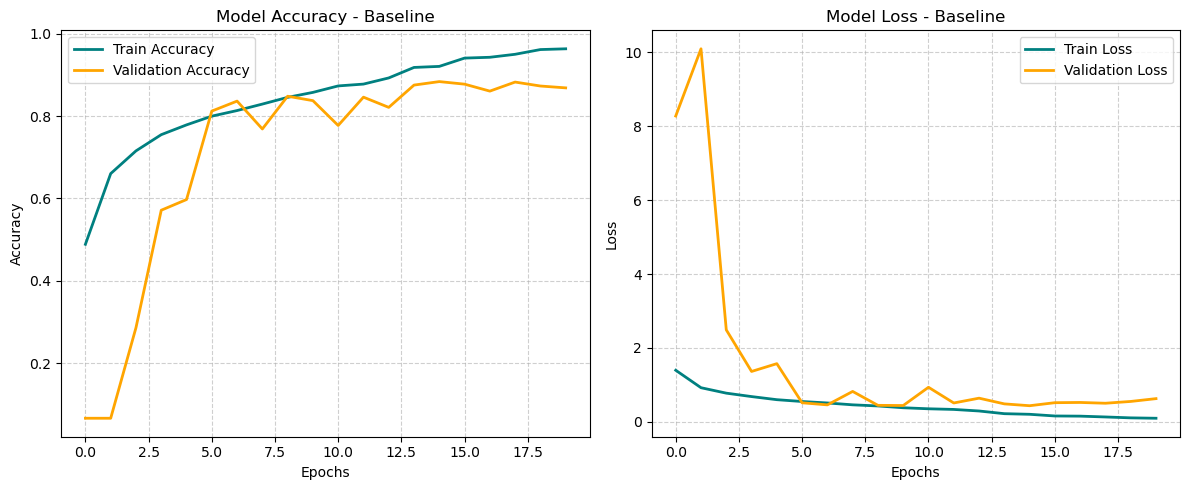

In [74]:
plot_training_history(history_baseline, experiment_name="Baseline")

# Test set

Evaluating model on Test Set...
56/56 [==============================] - 0s 2ms/step

--- Classification Report ---
              precision    recall  f1-score   support

      center       0.95      0.97      0.96       300
       donut       0.92      0.80      0.85        55
    edge-loc       0.84      0.86      0.85       300
   edge-ring       0.97      0.97      0.97       300
         loc       0.80      0.74      0.77       300
   near-full       1.00      0.93      0.97        15
        none       0.79      0.89      0.84       300
      random       0.90      0.95      0.93        87
     scratch       0.77      0.58      0.66       120

    accuracy                           0.87      1777
   macro avg       0.88      0.86      0.87      1777
weighted avg       0.87      0.87      0.87      1777

Plotting Confusion Matrix...


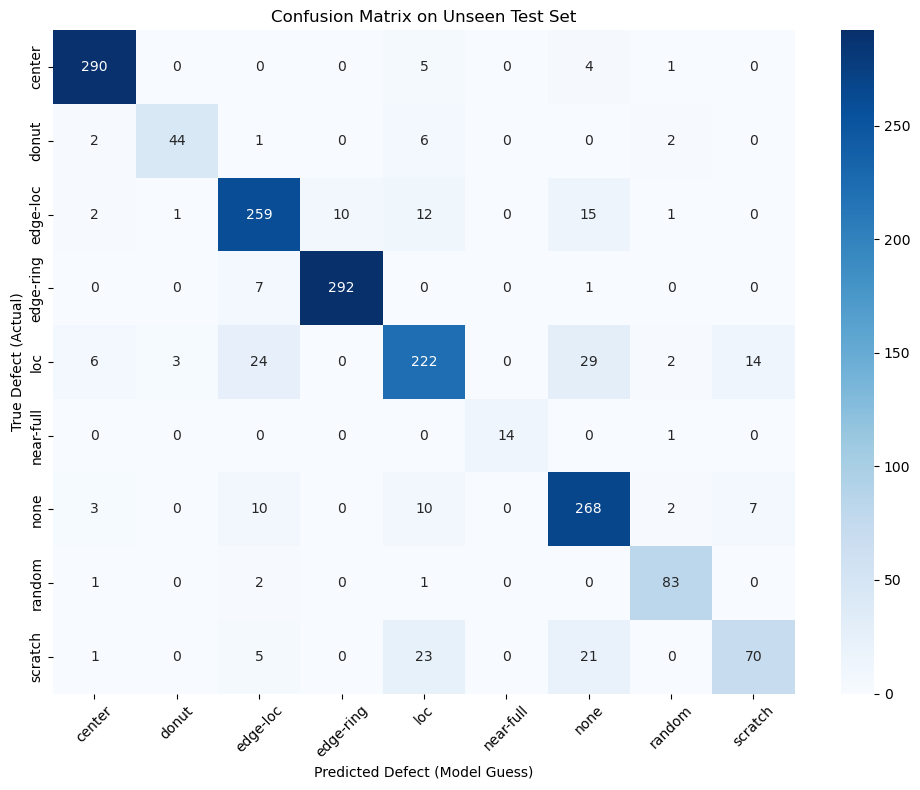

In [75]:
# 1. Get model predictions on the unseen Test Set
print("Evaluating model on Test Set...")
y_pred_probs = model_baseline.predict(X_test)

# Convert probability arrays back to class integers 
# (e.g., [0.1, 0.8, 0.1, ...] becomes class index 1)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test_categorical, axis=1)

# 2. Generate the Classification Report
# We retrieve the actual text names of the defects from our encoder
class_names = encoder.classes_

print("\n--- Classification Report ---")
# This will show Precision, Recall, and F1-Score for each specific defect
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))

# 3. Plot the Confusion Matrix
print("Plotting Confusion Matrix...")
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
# We use a heatmap to visually highlight where the model makes mistakes
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_names, 
    yticklabels=class_names
)
plt.title('Confusion Matrix on Unseen Test Set')
plt.ylabel('True Defect (Actual)')
plt.xlabel('Predicted Defect (Model Guess)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Experiment 1: Only He Initialization

In [76]:
model_exp1 = build_optimized_model(
    use_he=True, 
    use_l2=False, 
    optimizer='adam'
)

# Define Callbacks with a RECOGNIZABLE file name
callbacks_exp1 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    # Explicit and recognizable filename for this specific experiment
    ModelCheckpoint(filepath='exp1_he_initialization.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
]

# Train the model
print("\nStarting training for Experiment 1...")
history_exp1 = model_exp1.fit(
    X_train, 
    y_train_categorical,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val_categorical),
    callbacks=callbacks_exp1,
    verbose=1
)

-> Applying He Initialization

Starting training for Experiment 1...
Epoch 1/50
223/223 [==============================] - ETA: 0s - loss: 1.3578 - accuracy: 0.5163
Epoch 1: val_accuracy improved from -inf to 0.16892, saving model to exp1_he_initialization.h5
223/223 [==============================] - 2s 9ms/step - loss: 1.3578 - accuracy: 0.5163 - val_loss: 16.7257 - val_accuracy: 0.1689 - lr: 0.0010
Epoch 2/50
221/223 [============================>.] - ETA: 0s - loss: 0.9276 - accuracy: 0.6524
Epoch 2: val_accuracy did not improve from 0.16892
223/223 [==============================] - 2s 7ms/step - loss: 0.9278 - accuracy: 0.6521 - val_loss: 8.1363 - val_accuracy: 0.1639 - lr: 0.0010
Epoch 3/50
223/223 [==============================] - ETA: 0s - loss: 0.7922 - accuracy: 0.7032
Epoch 3: val_accuracy improved from 0.16892 to 0.60755, saving model to exp1_he_initialization.h5
223/223 [==============================] - 2s 9ms/step - loss: 0.7922 - accuracy: 0.7032 - val_loss: 1.0500 - 

Plotting learning curves for Exp 1 (He Init)...


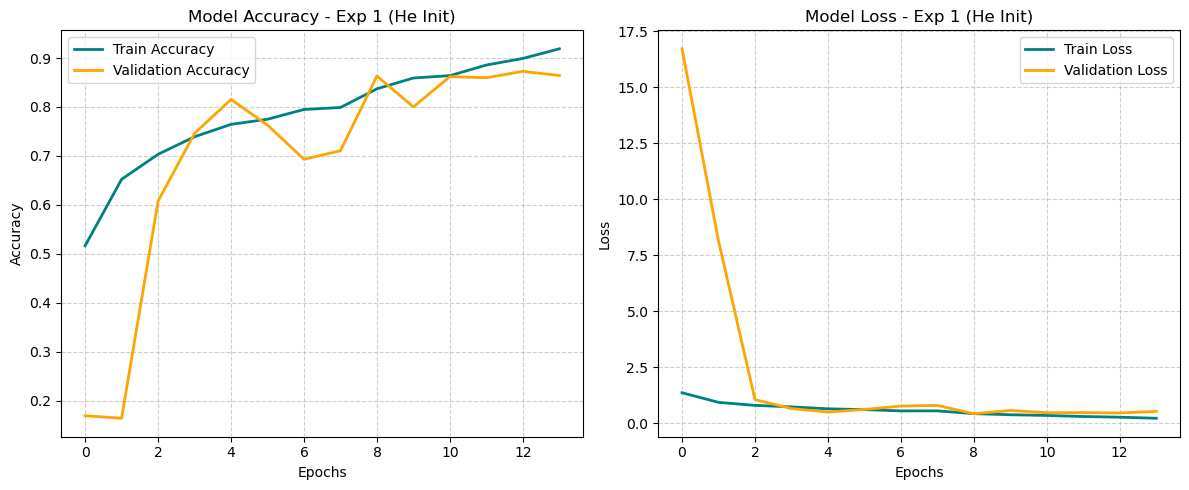

In [77]:
plot_training_history(history_exp1, experiment_name="Exp 1 (He Init)")

# Testing

Evaluating model on Test Set...
56/56 [==============================] - 0s 2ms/step

--- Classification Report ---
              precision    recall  f1-score   support

      center       0.92      0.96      0.94       300
       donut       0.88      0.84      0.86        55
    edge-loc       0.84      0.85      0.84       300
   edge-ring       0.99      0.93      0.96       300
         loc       0.74      0.76      0.75       300
   near-full       0.93      0.87      0.90        15
        none       0.77      0.91      0.83       300
      random       0.85      0.87      0.86        87
     scratch       0.61      0.32      0.42       120

    accuracy                           0.84      1777
   macro avg       0.84      0.81      0.82      1777
weighted avg       0.84      0.84      0.83      1777

Plotting Confusion Matrix...


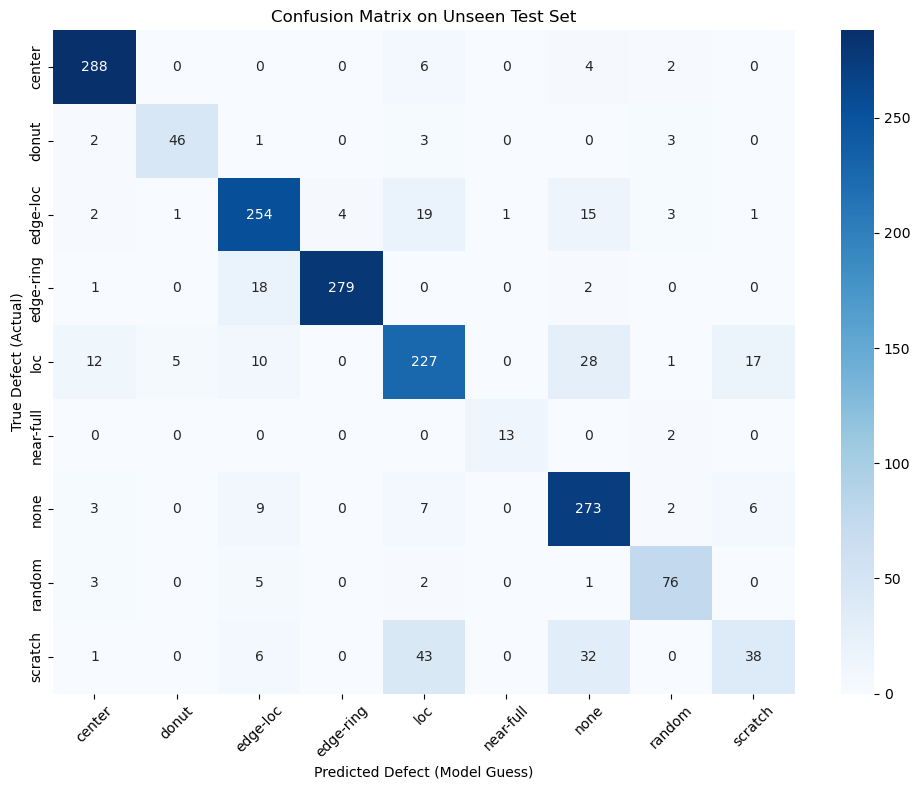

In [78]:
# 1. Get model predictions on the unseen Test Set
print("Evaluating model on Test Set...")
y_pred_probs = model_exp1.predict(X_test)

# Convert probability arrays back to class integers 
# (e.g., [0.1, 0.8, 0.1, ...] becomes class index 1)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test_categorical, axis=1)

# 2. Generate the Classification Report
# We retrieve the actual text names of the defects from our encoder
class_names = encoder.classes_

print("\n--- Classification Report ---")
# This will show Precision, Recall, and F1-Score for each specific defect
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))

# 3. Plot the Confusion Matrix
print("Plotting Confusion Matrix...")
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
# We use a heatmap to visually highlight where the model makes mistakes
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_names, 
    yticklabels=class_names
)
plt.title('Confusion Matrix on Unseen Test Set')
plt.ylabel('True Defect (Actual)')
plt.xlabel('Predicted Defect (Model Guess)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# EXPERIMENT 2: He Initialization + Data Augmentation

In [79]:
# 1. Build the model (He Initialization ON, L2 OFF)
model_exp2 = build_optimized_model(
    use_he=True, 
    use_l2=False, 
    optimizer='adam'
)

# 2. Create the "CPU Factory" for Data Augmentation
print("Setting up the ImageDataGenerator...")
datagen = ImageDataGenerator(
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=72  # Randomly rotates the image up to 72 degrees
)

# 3. Define Callbacks
callbacks_exp2 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    # Save this specific experiment's weights
    ModelCheckpoint(filepath='exp2_he_and_aug.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
]

# 4. Train the model using the generator
print("\nStarting training for Experiment 2...")
history_exp2 = model_exp2.fit(
    # We feed the generator which produces augmented batches on-the-fly
    datagen.flow(X_train, y_train_categorical, batch_size=64, seed=SEED),
    epochs=50,
    # Validation data is NEVER augmented, we test on clean real data
    validation_data=(X_val, y_val_categorical),
    callbacks=callbacks_exp2,
    verbose=1
)

-> Applying He Initialization
Setting up the ImageDataGenerator...

Starting training for Experiment 2...
Epoch 1/50
223/223 [==============================] - ETA: 0s - loss: 1.4170 - accuracy: 0.4963
Epoch 1: val_accuracy improved from -inf to 0.06700, saving model to exp2_he_and_aug.h5
223/223 [==============================] - 5s 23ms/step - loss: 1.4170 - accuracy: 0.4963 - val_loss: 25.5692 - val_accuracy: 0.0670 - lr: 0.0010
Epoch 2/50
223/223 [==============================] - ETA: 0s - loss: 1.0096 - accuracy: 0.6211
Epoch 2: val_accuracy did not improve from 0.06700
223/223 [==============================] - 5s 22ms/step - loss: 1.0096 - accuracy: 0.6211 - val_loss: 15.7751 - val_accuracy: 0.0670 - lr: 0.0010
Epoch 3/50
221/223 [============================>.] - ETA: 0s - loss: 0.9153 - accuracy: 0.6647
Epoch 3: val_accuracy improved from 0.06700 to 0.69876, saving model to exp2_he_and_aug.h5
223/223 [==============================] - 5s 21ms/step - loss: 0.9152 - accuracy: 0

Plotting learning curves for Exp 2 (He Init + Data Augmentation)...


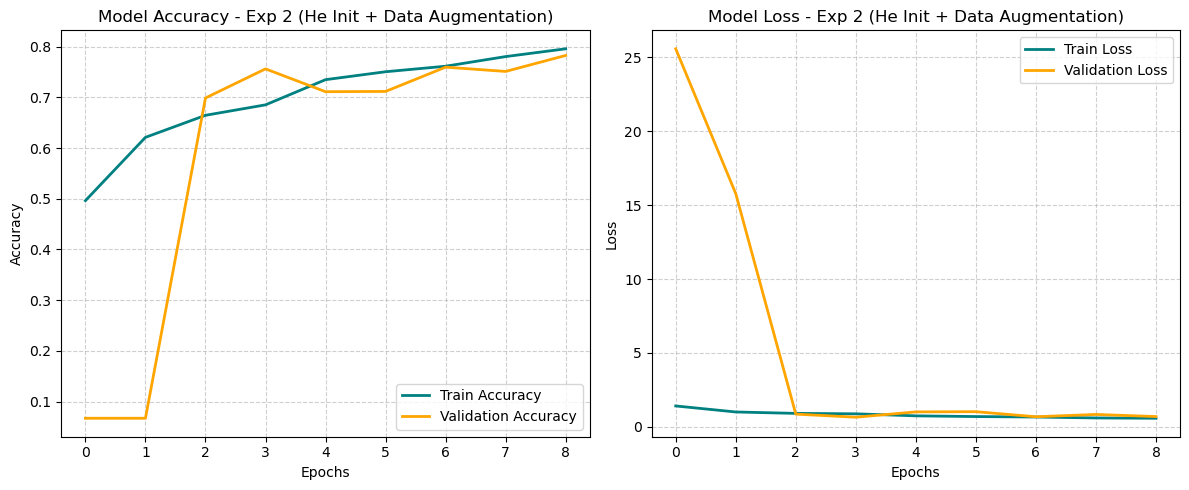

In [80]:
plot_training_history(history_exp2, experiment_name="Exp 2 (He Init + Data Augmentation)")

Evaluating Exp 2 model on Test Set...
56/56 [==============================] - 0s 2ms/step

--- Classification Report (Exp 2) ---
              precision    recall  f1-score   support

      center       0.91      0.90      0.90       300
       donut       0.88      0.51      0.64        55
    edge-loc       0.73      0.75      0.74       300
   edge-ring       0.98      0.91      0.94       300
         loc       0.68      0.54      0.60       300
   near-full       1.00      0.07      0.12        15
        none       0.58      0.93      0.71       300
      random       0.72      0.92      0.81        87
     scratch       0.40      0.08      0.14       120

    accuracy                           0.75      1777
   macro avg       0.76      0.62      0.62      1777
weighted avg       0.75      0.75      0.73      1777

Plotting Confusion Matrix...


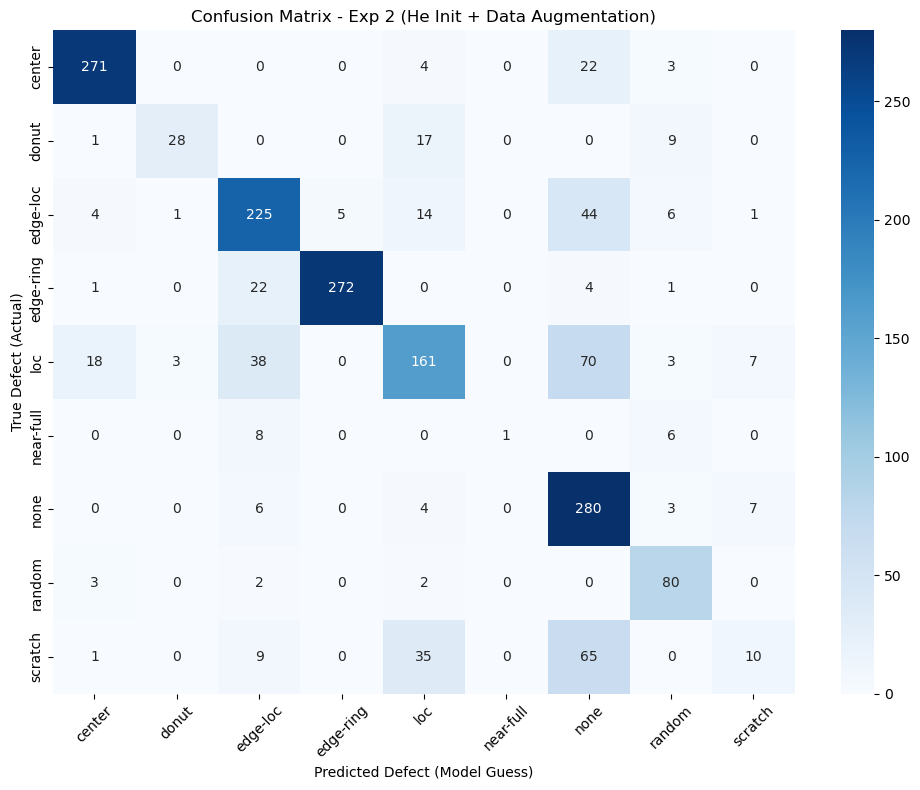

In [81]:
# 1. Get model predictions using the SPECIFIC model from Experiment 2
print("Evaluating Exp 2 model on Test Set...")
y_pred_probs_exp2 = model_exp2.predict(X_test)

# Convert probability arrays back to class integers 
y_pred_classes_exp2 = np.argmax(y_pred_probs_exp2, axis=1)
y_true_classes = np.argmax(y_test_categorical, axis=1)

# 2. Generate the Classification Report
class_names = encoder.classes_

print("\n--- Classification Report (Exp 2) ---")
print(classification_report(y_true_classes, y_pred_classes_exp2, target_names=class_names))

# 3. Plot the Confusion Matrix
print("Plotting Confusion Matrix...")
cm_exp2 = confusion_matrix(y_true_classes, y_pred_classes_exp2)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_exp2, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_names, 
    yticklabels=class_names
)
plt.title('Confusion Matrix - Exp 2 (He Init + Data Augmentation)')
plt.ylabel('True Defect (Actual)')
plt.xlabel('Predicted Defect (Model Guess)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Safe Augmentation

In [82]:
# Build the model with He Init
model_confirm = build_optimized_model(
    use_he=True, 
    use_l2=False, # Teniamo L2 spento per isolare l'effetto della sola Augmentation
    optimizer='adam'
)

# Safe Augmentation
datagen_safe = ImageDataGenerator(
    horizontal_flip=True,
    vertical_flip=True
)

# Training
history_confirm = model_confirm.fit(
    datagen_safe.flow(X_train, y_train_categorical, batch_size=64, seed=SEED),
    epochs=50,
    validation_data=(X_val, y_val_categorical),
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),  # ← aggiungere
        ModelCheckpoint(filepath='confirm_safe_aug.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
    ],
    verbose=1
)

-> Applying He Initialization
Epoch 1/50
219/223 [============================>.] - ETA: 0s - loss: 1.4432 - accuracy: 0.4761
Epoch 1: val_accuracy improved from -inf to 0.16892, saving model to confirm_safe_aug.h5
223/223 [==============================] - 3s 11ms/step - loss: 1.4371 - accuracy: 0.4776 - val_loss: 12.7641 - val_accuracy: 0.1689 - lr: 0.0010
Epoch 2/50
218/223 [============================>.] - ETA: 0s - loss: 1.0417 - accuracy: 0.6025
Epoch 2: val_accuracy did not improve from 0.16892
223/223 [==============================] - 2s 9ms/step - loss: 1.0382 - accuracy: 0.6037 - val_loss: 8.5697 - val_accuracy: 0.1689 - lr: 0.0010
Epoch 3/50
218/223 [============================>.] - ETA: 0s - loss: 0.9273 - accuracy: 0.6505
Epoch 3: val_accuracy improved from 0.16892 to 0.41779, saving model to confirm_safe_aug.h5
223/223 [==============================] - 2s 10ms/step - loss: 0.9268 - accuracy: 0.6512 - val_loss: 1.9705 - val_accuracy: 0.4178 - lr: 0.0010
Epoch 4/50
218/

Plotting learning curves for Confirmation (He Init + Safe Augmentation)...


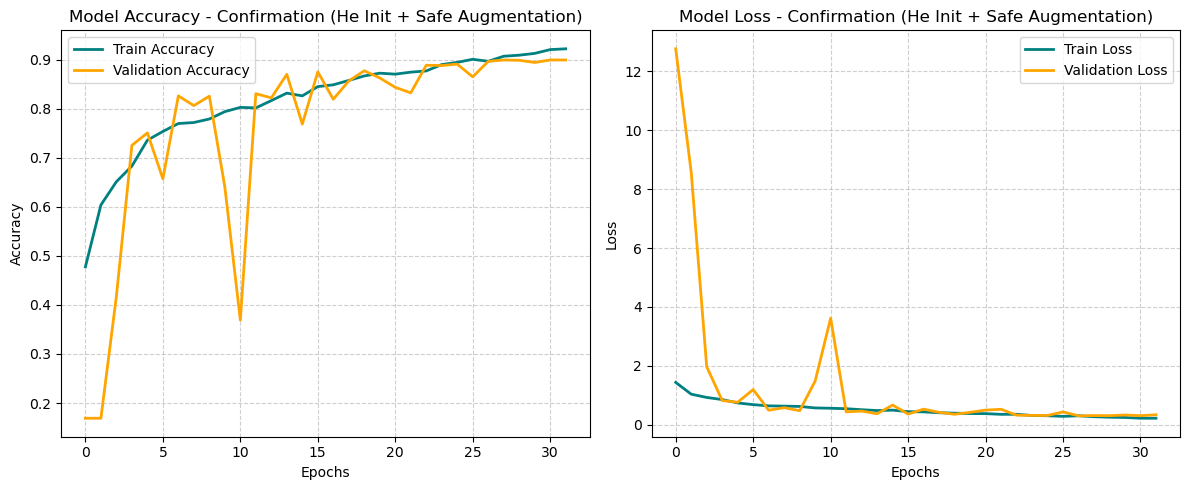

In [83]:
plot_training_history(history_confirm, experiment_name="Confirmation (He Init + Safe Augmentation)")

56/56 [==============================] - 0s 2ms/step

--- Classification Report (Exp 2) ---
              precision    recall  f1-score   support

      center       0.96      0.95      0.95       300
       donut       0.93      0.78      0.85        55
    edge-loc       0.89      0.85      0.87       300
   edge-ring       0.96      0.99      0.98       300
         loc       0.78      0.86      0.82       300
   near-full       1.00      1.00      1.00        15
        none       0.93      0.89      0.91       300
      random       0.86      0.93      0.90        87
     scratch       0.86      0.80      0.83       120

    accuracy                           0.90      1777
   macro avg       0.91      0.90      0.90      1777
weighted avg       0.90      0.90      0.90      1777

Plotting Confusion Matrix...


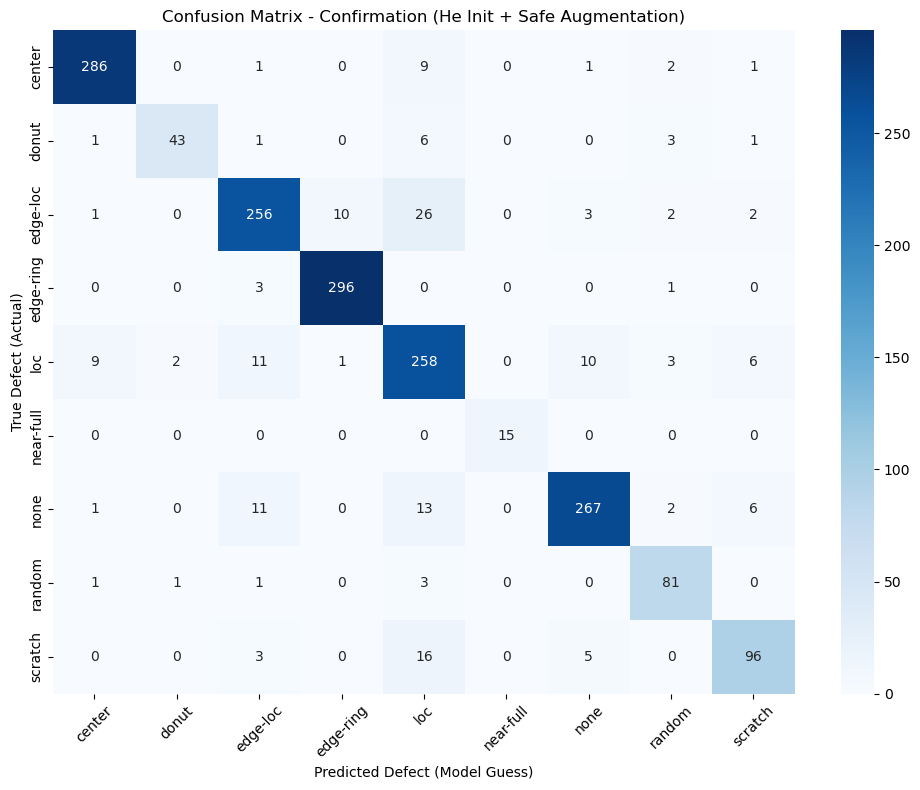

In [84]:
y_pred_probs_conf = model_confirm.predict(X_test)

# Convert probability arrays back to class integers 
y_pred_classes_conf = np.argmax(y_pred_probs_conf, axis=1)
y_true_classes = np.argmax(y_test_categorical, axis=1)

# 2. Generate the Classification Report
class_names = encoder.classes_

print("\n--- Classification Report (Exp 2) ---")
print(classification_report(y_true_classes, y_pred_classes_conf, target_names=class_names))

# 3. Plot the Confusion Matrix
print("Plotting Confusion Matrix...")
cm_conf = confusion_matrix(y_true_classes, y_pred_classes_conf)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_conf, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_names, 
    yticklabels=class_names
)
plt.title('Confusion Matrix - Confirmation (He Init + Safe Augmentation)')
plt.ylabel('True Defect (Actual)')
plt.xlabel('Predicted Defect (Model Guess)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# EXPERIMENT 3: He Init + Safe Flips + L2 Regularization

In [85]:
# 1. Build the model (He Init ON, L2 Regularization ON)
model_exp3 = build_optimized_model(
    use_he=True, 
    use_l2=True,
    optimizer='adam'
)

# 2. Create the "Safe CPU Factory" for Data Augmentation
print("Setting up the safe ImageDataGenerator...")
datagen_safe = ImageDataGenerator(
    horizontal_flip=True,
    vertical_flip=True
    # Rimosso rotation_range per evitare che l'interpolazione cancelli i graffi!
)

# 3. Define Callbacks
callbacks_exp3 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint(filepath='exp3_safe_aug_l2.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
]

# 4. Train the model using the SAFE generator
print("\nStarting training for Experiment 3...")
history_exp3 = model_exp3.fit(
    datagen_safe.flow(X_train, y_train_categorical, batch_size=64, seed=SEED),
    epochs=50,
    validation_data=(X_val, y_val_categorical),
    callbacks=callbacks_exp3,
    verbose=1
)

-> Applying He Initialization
-> Applying L2 Regularization
Setting up the safe ImageDataGenerator...

Starting training for Experiment 3...
Epoch 1/50
220/223 [============================>.] - ETA: 0s - loss: 2.1234 - accuracy: 0.4893
Epoch 1: val_accuracy improved from -inf to 0.16892, saving model to exp3_safe_aug_l2.h5
223/223 [==============================] - 3s 11ms/step - loss: 2.1179 - accuracy: 0.4909 - val_loss: 21.2858 - val_accuracy: 0.1689 - lr: 0.0010
Epoch 2/50
221/223 [============================>.] - ETA: 0s - loss: 1.5438 - accuracy: 0.6317
Epoch 2: val_accuracy did not improve from 0.16892
223/223 [==============================] - 2s 10ms/step - loss: 1.5446 - accuracy: 0.6315 - val_loss: 11.5797 - val_accuracy: 0.1689 - lr: 0.0010
Epoch 3/50
222/223 [============================>.] - ETA: 0s - loss: 1.3485 - accuracy: 0.6785
Epoch 3: val_accuracy improved from 0.16892 to 0.57601, saving model to exp3_safe_aug_l2.h5
223/223 [==============================] - 2s 1

Plotting learning curves for Exp 3 (He Init + Safe Aug + L2)...


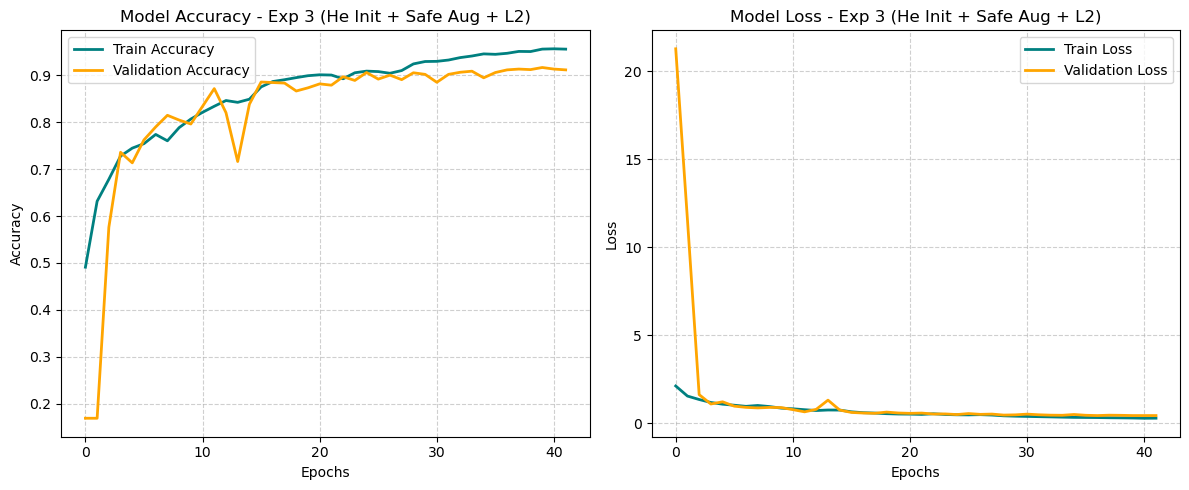

In [86]:
# Execute the plotting function using the history from Experiment 3
plot_training_history(history_exp3, experiment_name="Exp 3 (He Init + Safe Aug + L2)")

Evaluating Exp 3 model on Test Set...
56/56 [==============================] - 0s 2ms/step

--- Classification Report (Exp 3) ---
              precision    recall  f1-score   support

      center       0.95      0.97      0.96       300
       donut       0.90      0.85      0.88        55
    edge-loc       0.90      0.85      0.87       300
   edge-ring       0.99      0.99      0.99       300
         loc       0.82      0.82      0.82       300
   near-full       0.93      0.87      0.90        15
        none       0.88      0.93      0.90       300
      random       0.86      0.94      0.90        87
     scratch       0.90      0.84      0.87       120

    accuracy                           0.91      1777
   macro avg       0.90      0.90      0.90      1777
weighted avg       0.91      0.91      0.91      1777

Plotting Confusion Matrix...


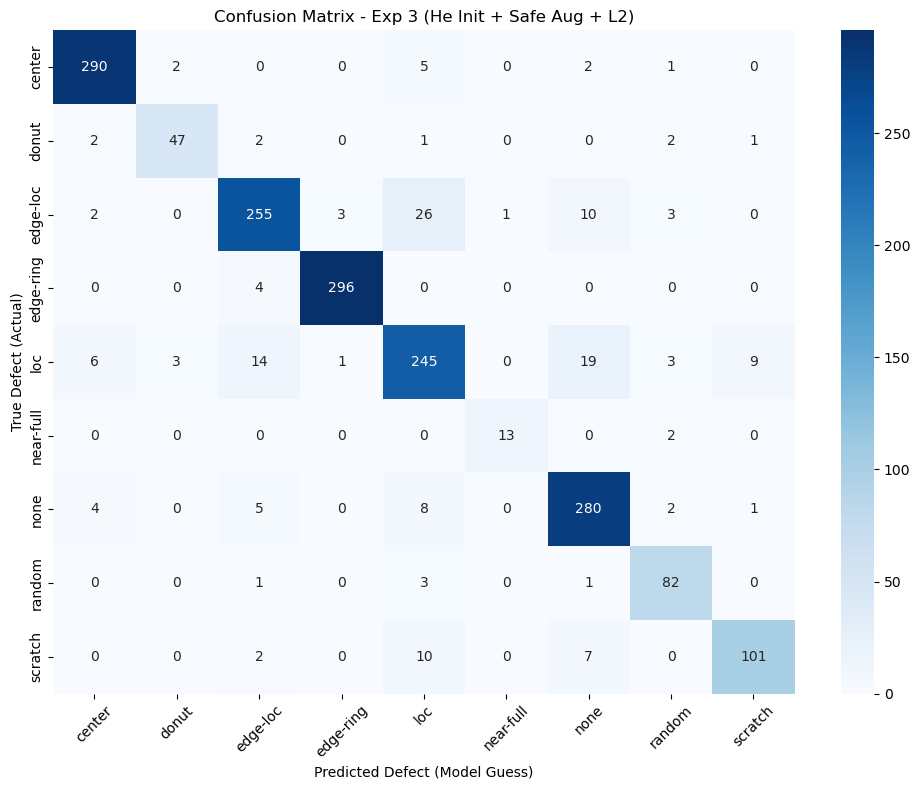

In [87]:
# 1. Get model predictions using the SPECIFIC model from Experiment 3
print("Evaluating Exp 3 model on Test Set...")
y_pred_probs_exp3 = model_exp3.predict(X_test)

# Convert probability arrays back to class integers 
y_pred_classes_exp3 = np.argmax(y_pred_probs_exp3, axis=1)
y_true_classes = np.argmax(y_test_categorical, axis=1)

# 2. Generate the Classification Report
class_names = encoder.classes_

print("\n--- Classification Report (Exp 3) ---")
print(classification_report(y_true_classes, y_pred_classes_exp3, target_names=class_names))

# 3. Plot the Confusion Matrix
print("Plotting Confusion Matrix...")
cm_exp3 = confusion_matrix(y_true_classes, y_pred_classes_exp3)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_exp3, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_names, 
    yticklabels=class_names
)
plt.title('Confusion Matrix - Exp 3 (He Init + Safe Aug + L2)')
plt.ylabel('True Defect (Actual)')
plt.xlabel('Predicted Defect (Model Guess)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
print("--- FINAL MODEL COMPARISON ---")

# 1. Configurazione modelli per il caricamento dei pesi
models_config = {
    "Baseline CNN": {"file": "baseline.h5", "he": False, "l2": False},
    "Exp 1 (He Init)": {"file": "exp1_he_initialization.h5", "he": True, "l2": False},
    "Exp 2 (Bad Aug)": {"file": "exp2_he_and_aug.h5", "he": True, "l2": False},
    "Confirmation Exp": {"file": "confirm_safe_aug.h5", "he": True, "l2": False},
    "Exp 3 (Safe Aug + L2)": {"file": "exp3_safe_aug_l2.h5", "he": True, "l2": True}
}

models_dict = {}
y_true = np.argmax(y_test_categorical, axis=1)
results_list = []
cm_dict = {}

# 2. Caricamento e Valutazione
for name, config in models_config.items():
    print(f"Loading and evaluating {name}...")
    model = build_optimized_model(use_he=config["he"], use_l2=config["l2"])
    model.load_weights(config["file"])
    models_dict[name] = model
    
    # Previsioni
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    # Metriche
    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred) # Nuova metrica aggiunta
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    
    results_list.append({
        "Model": name, 
        "Accuracy": round(acc * 100, 2), 
        "Balanced Accuracy": round(bal_acc * 100, 2), 
        "F1-Score": round(f1 * 100, 2)
    })
    cm_dict[name] = confusion_matrix(y_true, y_pred)

# 3. Tabella Risultati
benchmark_df = pd.DataFrame(results_list).set_index("Model")
display(benchmark_df)

--- FINAL MODEL COMPARISON ---
Loading and evaluating Baseline CNN...
Loading and evaluating Exp 1 (He Init)...
-> Applying He Initialization
Loading and evaluating Exp 2 (Bad Aug)...
-> Applying He Initialization
Loading and evaluating Confirmation Exp...
-> Applying He Initialization
Loading and evaluating Exp 3 (Safe Aug + L2)...
-> Applying He Initialization
-> Applying L2 Regularization


,Accuracy,Balanced Accuracy,F1-Score
Model,,,
Baseline CNN,86.78,85.64,86.65
Exp 1 (He Init),85.76,82.35,83.56
Exp 2 (Bad Aug),74.73,62.32,62.37
Confirmation Exp,88.80,88.28,89.11
Exp 3 (Safe Aug + L2),91.22,91.48,91.64


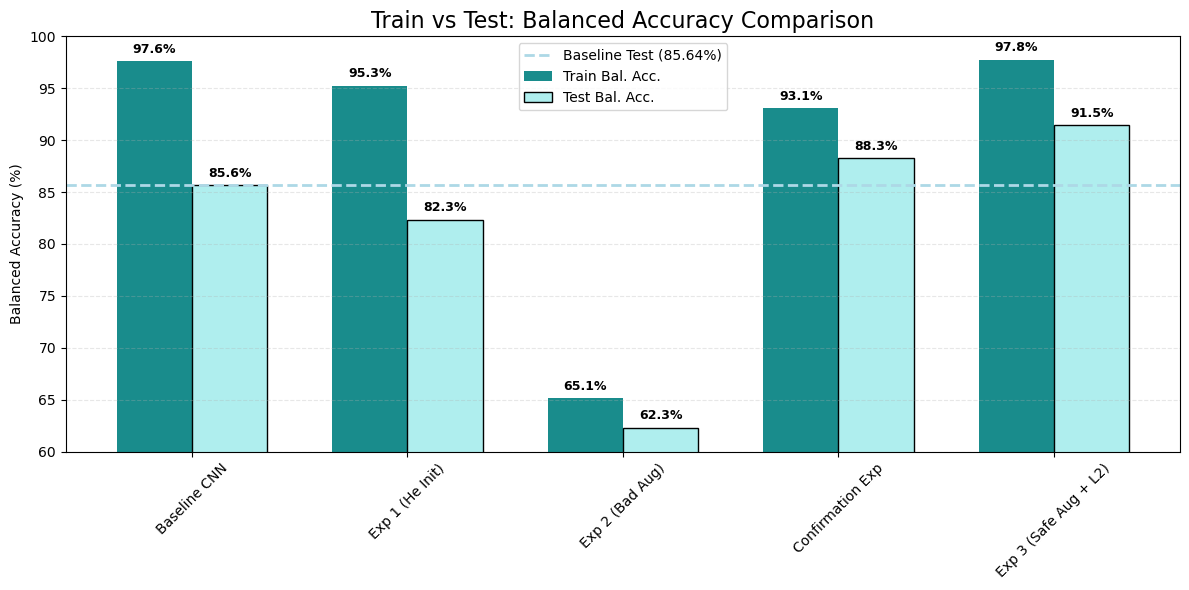

In [89]:
train_scores = []
test_scores = []
model_names = list(models_dict.keys())

for name in model_names:
    model = models_dict[name]
    
    # Valutazione Train
    y_train_pred = np.argmax(model.predict(X_train, verbose=0), axis=1)
    y_train_true = np.argmax(y_train_categorical, axis=1)
    train_scores.append(balanced_accuracy_score(y_train_true, y_train_pred) * 100)
    
    # Valutazione Test
    y_test_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    test_scores.append(balanced_accuracy_score(y_true, y_test_pred) * 100)

# 2. Setup grafico a doppia barra
x = np.arange(len(model_names))
width = 0.35 

plt.figure(figsize=(12, 6))

# Barre chiare (Test) e scure (Train)
rects1 = plt.bar(x - width/2, train_scores, width, label='Train Bal. Acc.', color='teal', alpha=0.9)
rects2 = plt.bar(x + width/2, test_scores, width, label='Test Bal. Acc.', color='paleturquoise', edgecolor='black')

# Linea Baseline (usa il valore di Test della Baseline)
plt.axhline(y=test_scores[0], color='lightblue', linestyle='--', linewidth=2, label=f'Baseline Test ({test_scores[0]:.2f}%)')

# 3. Formattazione
plt.ylim(60, 100)
plt.ylabel('Balanced Accuracy (%)')
plt.title('Train vs Test: Balanced Accuracy Comparison', fontsize=16)
plt.xticks(x, model_names, rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Funzione per aggiungere le etichette sopra le barre
def add_labels(rects):
    for rect in rects:
        height = rect.get_height()
        plt.text(rect.get_x() + rect.get_width()/2., height + 0.5,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

add_labels(rects1)
add_labels(rects2)

plt.tight_layout()
plt.show()

In [ ]:
# Safe augmentation — same as Exp 3
datagen_best = ImageDataGenerator(
    horizontal_flip=True,
    vertical_flip=True
)

OPTIMIZER_REGISTRY = {
    "Adam":           lambda: Adam(learning_rate=0.001),
    "SGD + Nesterov": lambda: SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
    "RMSprop":        lambda: RMSprop(learning_rate=0.001),
    "Nadam":          lambda: Nadam(learning_rate=0.001),
}

WEIGHT_FILES_BEST = {
    "Adam":           "best_adam.h5",
    "SGD + Nesterov": "best_sgd_nesterov.h5",
    "RMSprop":        "best_rmsprop.h5",
    "Nadam":          "best_nadam.h5",
}

histories_best = {}
models_best = {}

for opt_name, build_opt in OPTIMIZER_REGISTRY.items():
    print(f"\n{'='*55}")
    print(f"  Training Best Model with: {opt_name}")
    print(f"{'='*55}")

    # Same seed reset as before for fair initialization comparison
    tf.random.set_seed(SEED)
    np.random.seed(SEED)

    model = build_optimized_model(use_he=True, use_l2=True, optimizer=build_opt())

    history = model.fit(
        datagen_best.flow(X_train, y_train_categorical, batch_size=64, seed=SEED),
        epochs=50,
        validation_data=(X_val, y_val_categorical),
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=5,
                          restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                              patience=3, min_lr=1e-6, verbose=1),
            ModelCheckpoint(filepath=WEIGHT_FILES_BEST[opt_name],
                            monitor='val_accuracy',
                            save_best_only=True, verbose=0),
        ],
        verbose=1,
    )

    histories_best[opt_name] = history
    models_best[opt_name]    = model
    print(f"{opt_name} done")


  Training Best Model with: Adam
-> Applying He Initialization
-> Applying L2 Regularization
Epoch 1/50
223/223 [==============================] - 3s 11ms/step - loss: 2.1638 - accuracy: 0.4722 - val_loss: 11.8494 - val_accuracy: 0.0315 - lr: 0.0010
Epoch 2/50
223/223 [==============================] - 2s 10ms/step - loss: 1.6104 - accuracy: 0.6042 - val_loss: 7.6399 - val_accuracy: 0.0321 - lr: 0.0010
Epoch 3/50
223/223 [==============================] - 2s 11ms/step - loss: 1.4224 - accuracy: 0.6539 - val_loss: 2.6120 - val_accuracy: 0.3288 - lr: 0.0010
Epoch 4/50
223/223 [==============================] - 2s 11ms/step - loss: 1.2511 - accuracy: 0.7012 - val_loss: 1.0513 - val_accuracy: 0.7658 - lr: 0.0010
Epoch 5/50
223/223 [==============================] - 2s 10ms/step - loss: 1.1388 - accuracy: 0.7288 - val_loss: 1.0376 - val_accuracy: 0.7269 - lr: 0.0010
Epoch 6/50
223/223 [==============================] - 2s 10ms/step - loss: 1.0483 - accuracy: 0.7544 - val_loss: 0.8958 - val

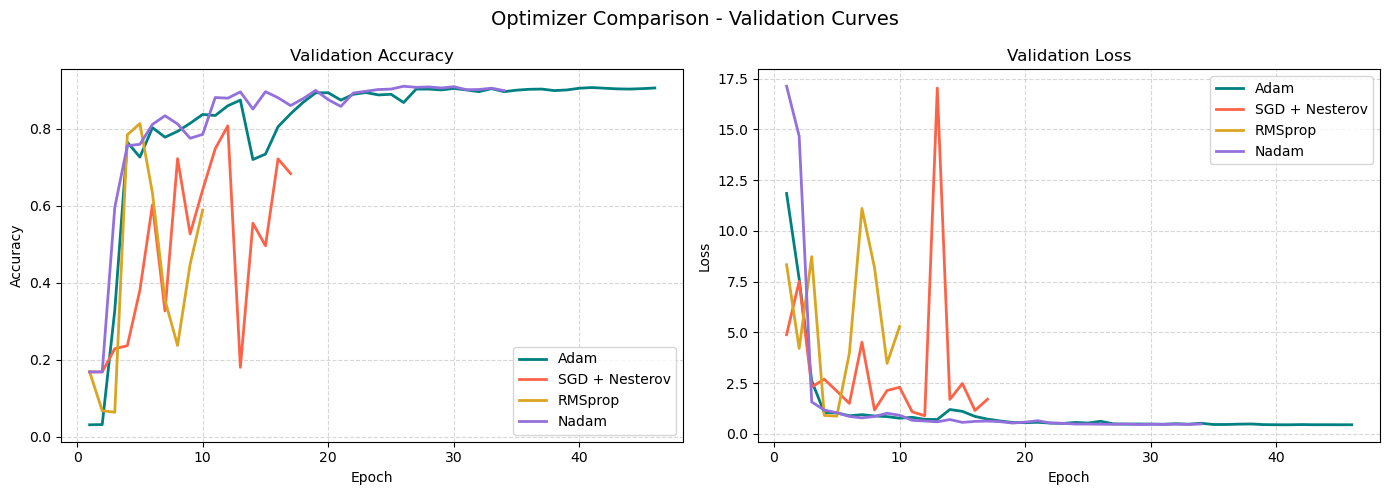

In [93]:
COLORS = ["teal", "tomato", "goldenrod", "mediumpurple"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Optimizer Comparison - Validation Curves", fontsize=14)

for (opt_name, history), color in zip(histories_best.items(), COLORS):
    epochs_range = range(1, len(history.history['val_accuracy']) + 1)

    axes[0].plot(epochs_range, history.history['val_accuracy'],
                 label=opt_name, color=color, linewidth=2)
    axes[1].plot(epochs_range, history.history['val_loss'],
                 label=opt_name, color=color, linewidth=2)

for ax, title, ylabel in zip(axes,
                               ["Validation Accuracy", "Validation Loss"],
                               ["Accuracy", "Loss"]):
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

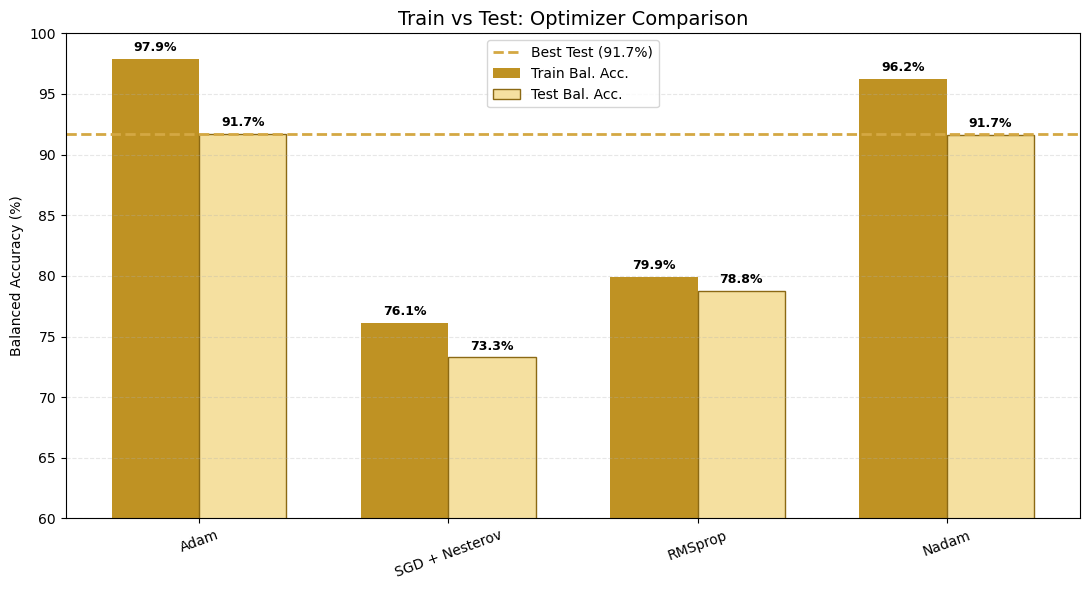

In [105]:
opt_names    = list(models_best.keys())
train_scores = []
test_scores  = []

y_train_true = np.argmax(y_train_categorical, axis=1)
y_test_true  = np.argmax(y_test_categorical,  axis=1)

for opt_name in opt_names:
    model = models_best[opt_name]

    y_train_pred = np.argmax(model.predict(X_train, verbose=0), axis=1)
    train_scores.append(balanced_accuracy_score(y_train_true, y_train_pred) * 100)

    y_test_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    test_scores.append(balanced_accuracy_score(y_test_true, y_test_pred) * 100)

# Plot 
x     = np.arange(len(opt_names))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))

bars_train = ax.bar(x - width / 2, train_scores, width,
                    label='Train Bal. Acc.',
                    color='#B8860B', alpha=0.9)          # dark goldenrod

bars_test  = ax.bar(x + width / 2, test_scores, width,
                    label='Test Bal. Acc.',
                    color='#F5E0A0', edgecolor='#8B6914') # pale ochre + dark border

best_test = max(test_scores)
ax.axhline(y=best_test, color='#D4A843', linestyle='--', linewidth=2,
           label=f'Best Test ({best_test:.1f}%)')          # mid ochre

def add_bar_labels(bars):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.4,
                f'{bar.get_height():.1f}%',
                ha='center', va='bottom',
                fontsize=9, fontweight='bold')

add_bar_labels(bars_train)
add_bar_labels(bars_test)

ax.set_ylim(60, 100)
ax.set_ylabel('Balanced Accuracy (%)')
ax.set_title('Train vs Test: Optimizer Comparison', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(opt_names, rotation=20)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [106]:
def visualize_original_and_maps(model, input_image, label_index, class_names):
    # 1. Configurazione del modello per estrarre gli output di ogni layer Conv2D
    layer_outputs = [layer.output for layer in model.layers if isinstance(layer, tf.keras.layers.Conv2D)]
    activation_model = tf.keras.models.Model(inputs=model.input, outputs=layer_outputs)
    activations = activation_model.predict(input_image[np.newaxis, ...], verbose=0)
    layer_names = [layer.name for layer in model.layers if isinstance(layer, tf.keras.layers.Conv2D)]
    
    # 2. Visualizza immagine originale con il nome della classe
    plt.figure(figsize=(2, 2))
    plt.imshow(input_image.reshape(56, 56), cmap='gray')
    
    # Recuperiamo il nome dalla lista usando l'indice
    label_name = class_names[label_index] 
    plt.title(f"Original\nClass: {label_name}")
    plt.axis('off')
    plt.show()
    
# 3. Visualizza feature maps per ogni strato
    for layer_name, layer_activation in zip(layer_names, activations):
        n_filters = layer_activation.shape[-1]
        cols = 16
        rows = math.ceil(n_filters / cols)

        fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.5, rows * 1.5), squeeze=False)
        axes_flat = axes.flatten()
        fig.suptitle(f'Layer: {layer_name}  ({n_filters} filters)', fontsize=12)

        for i in range(n_filters):
            axes_flat[i].imshow(layer_activation[0, :, :, i], cmap='viridis')
            axes_flat[i].axis('off')

        for i in range(n_filters, len(axes_flat)):
            axes_flat[i].axis('off')

        plt.tight_layout()
        plt.show()

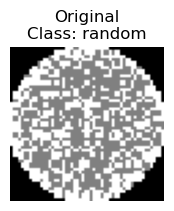

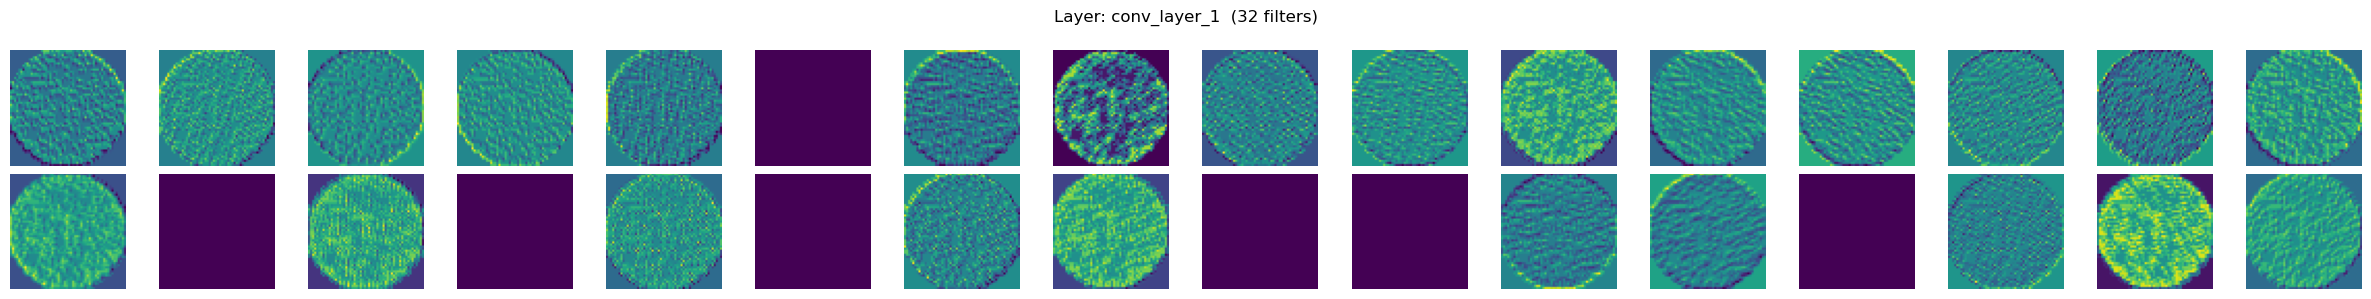

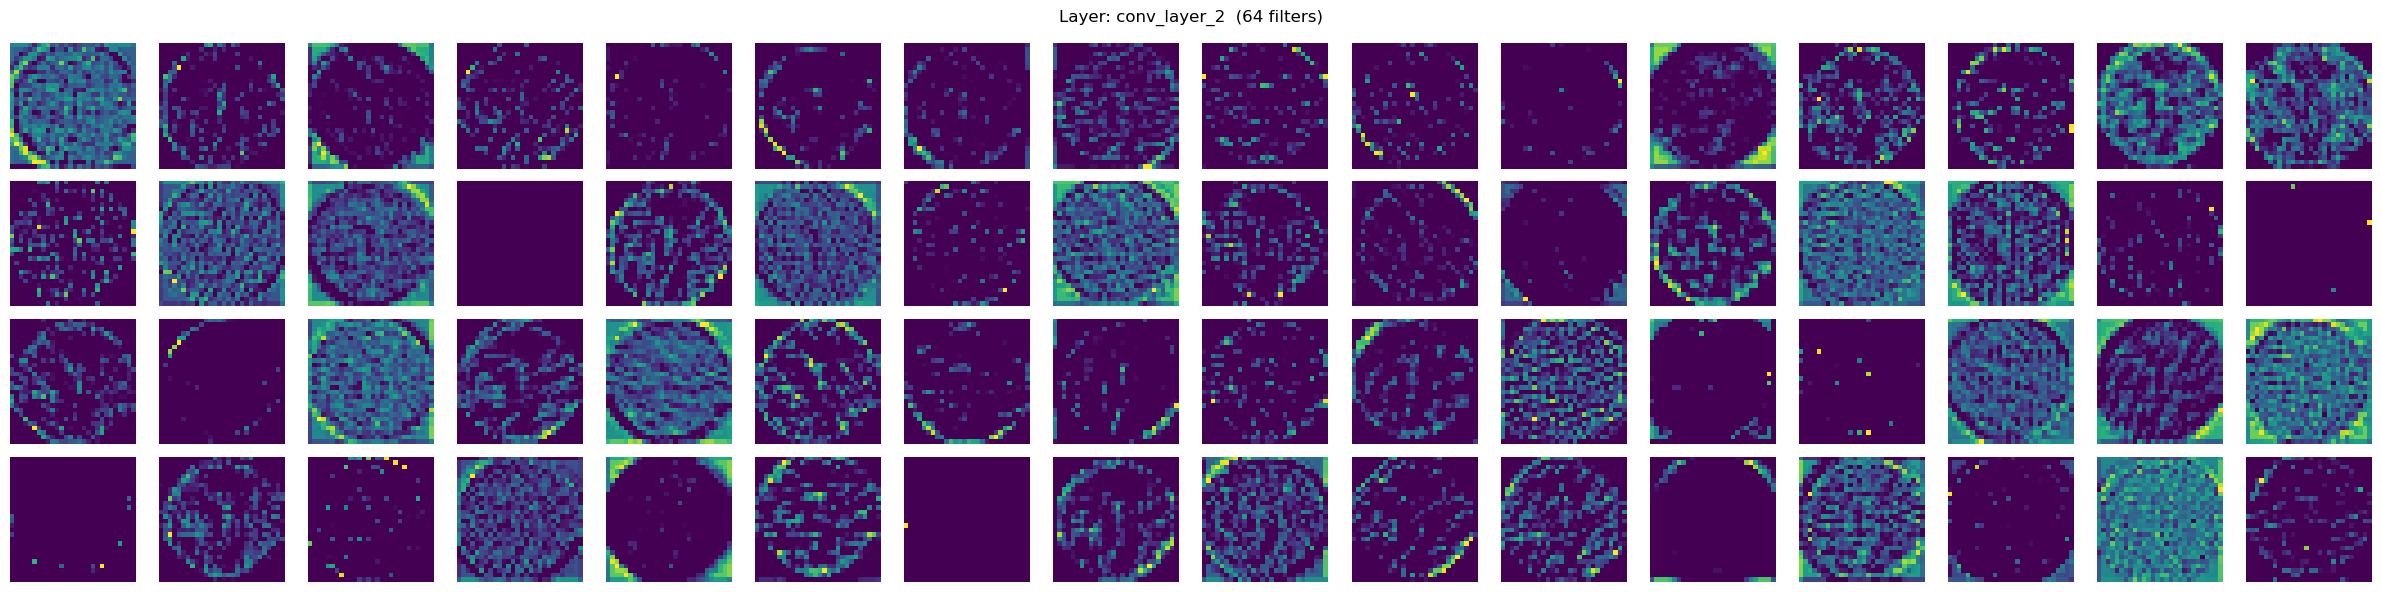

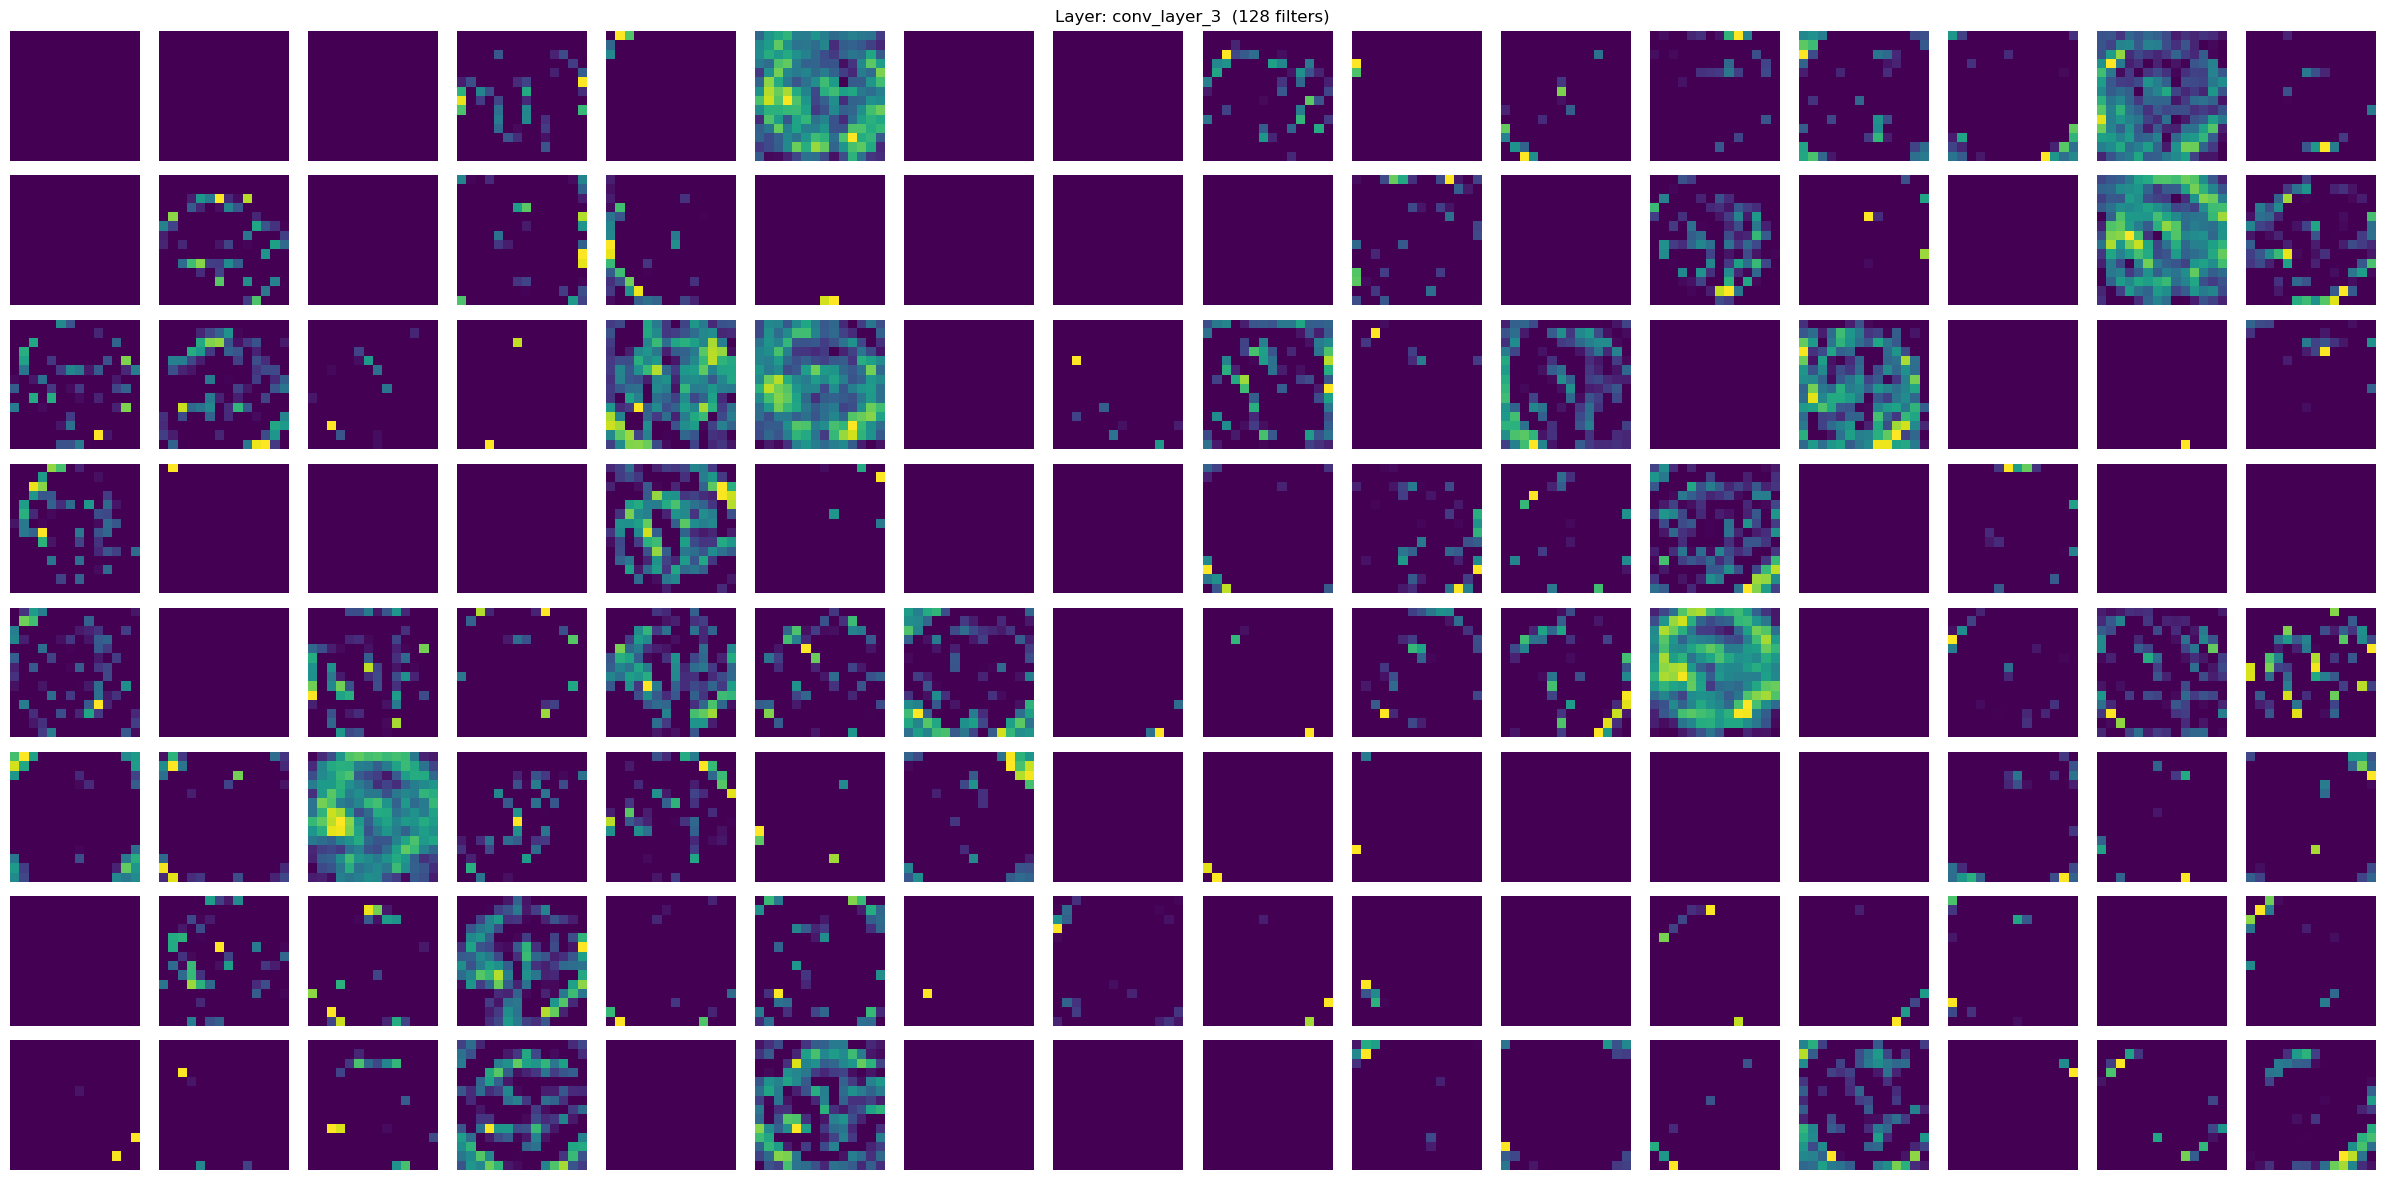

In [ ]:
# Modello dal training loop dei best models
idx = 300
visualize_original_and_maps(models_best["Nadam"], X_test[idx], y_true[idx], class_names)

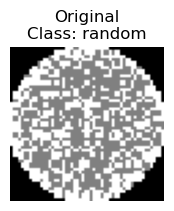

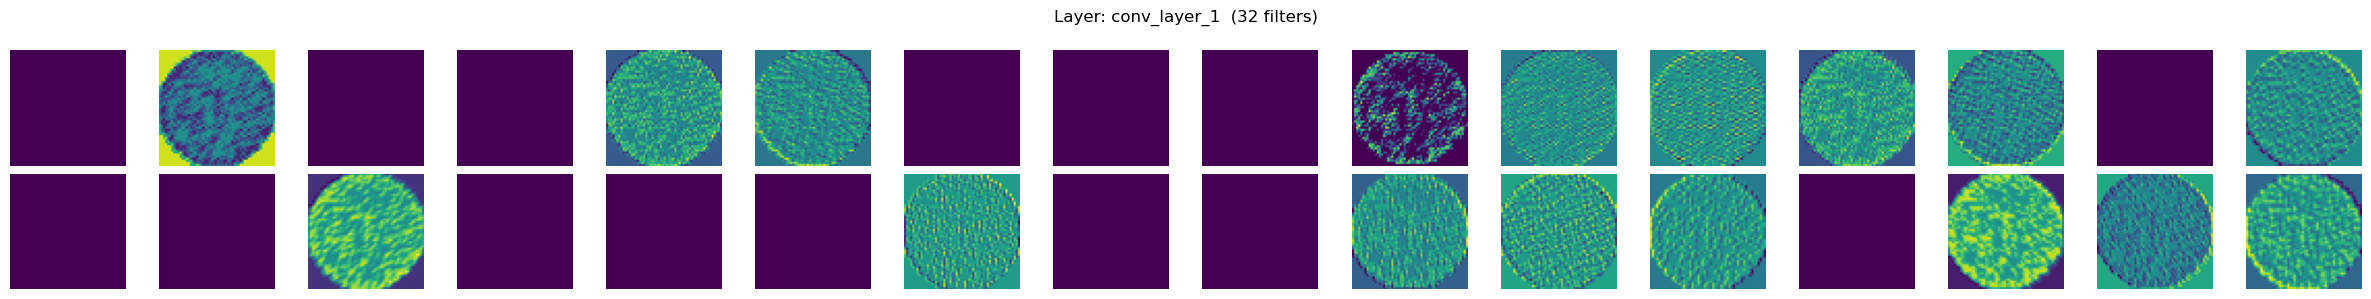

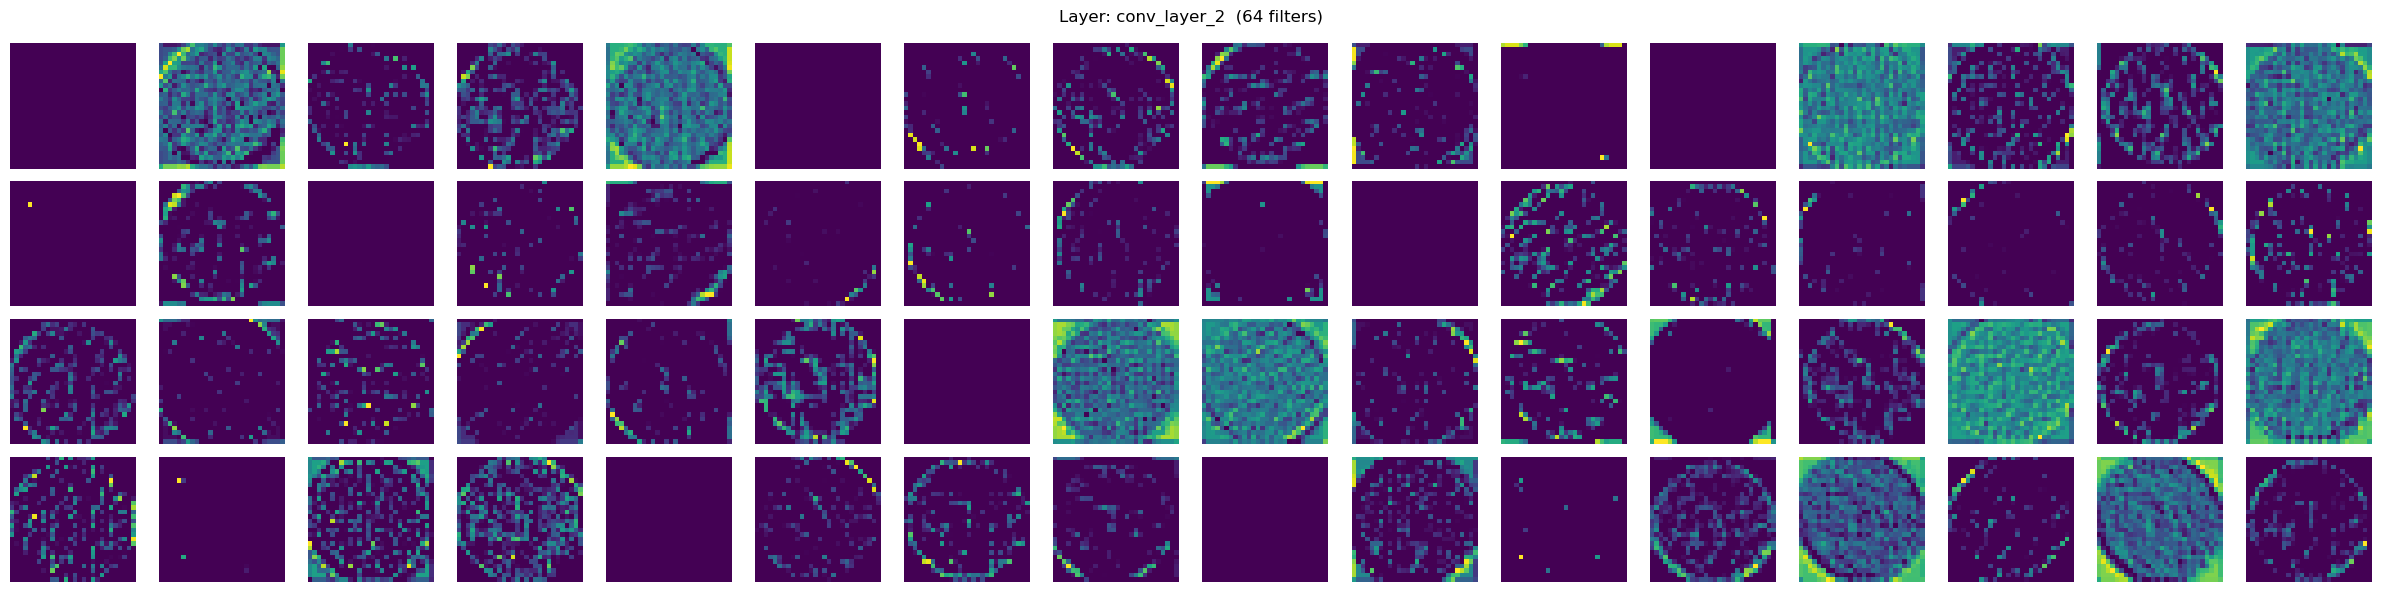

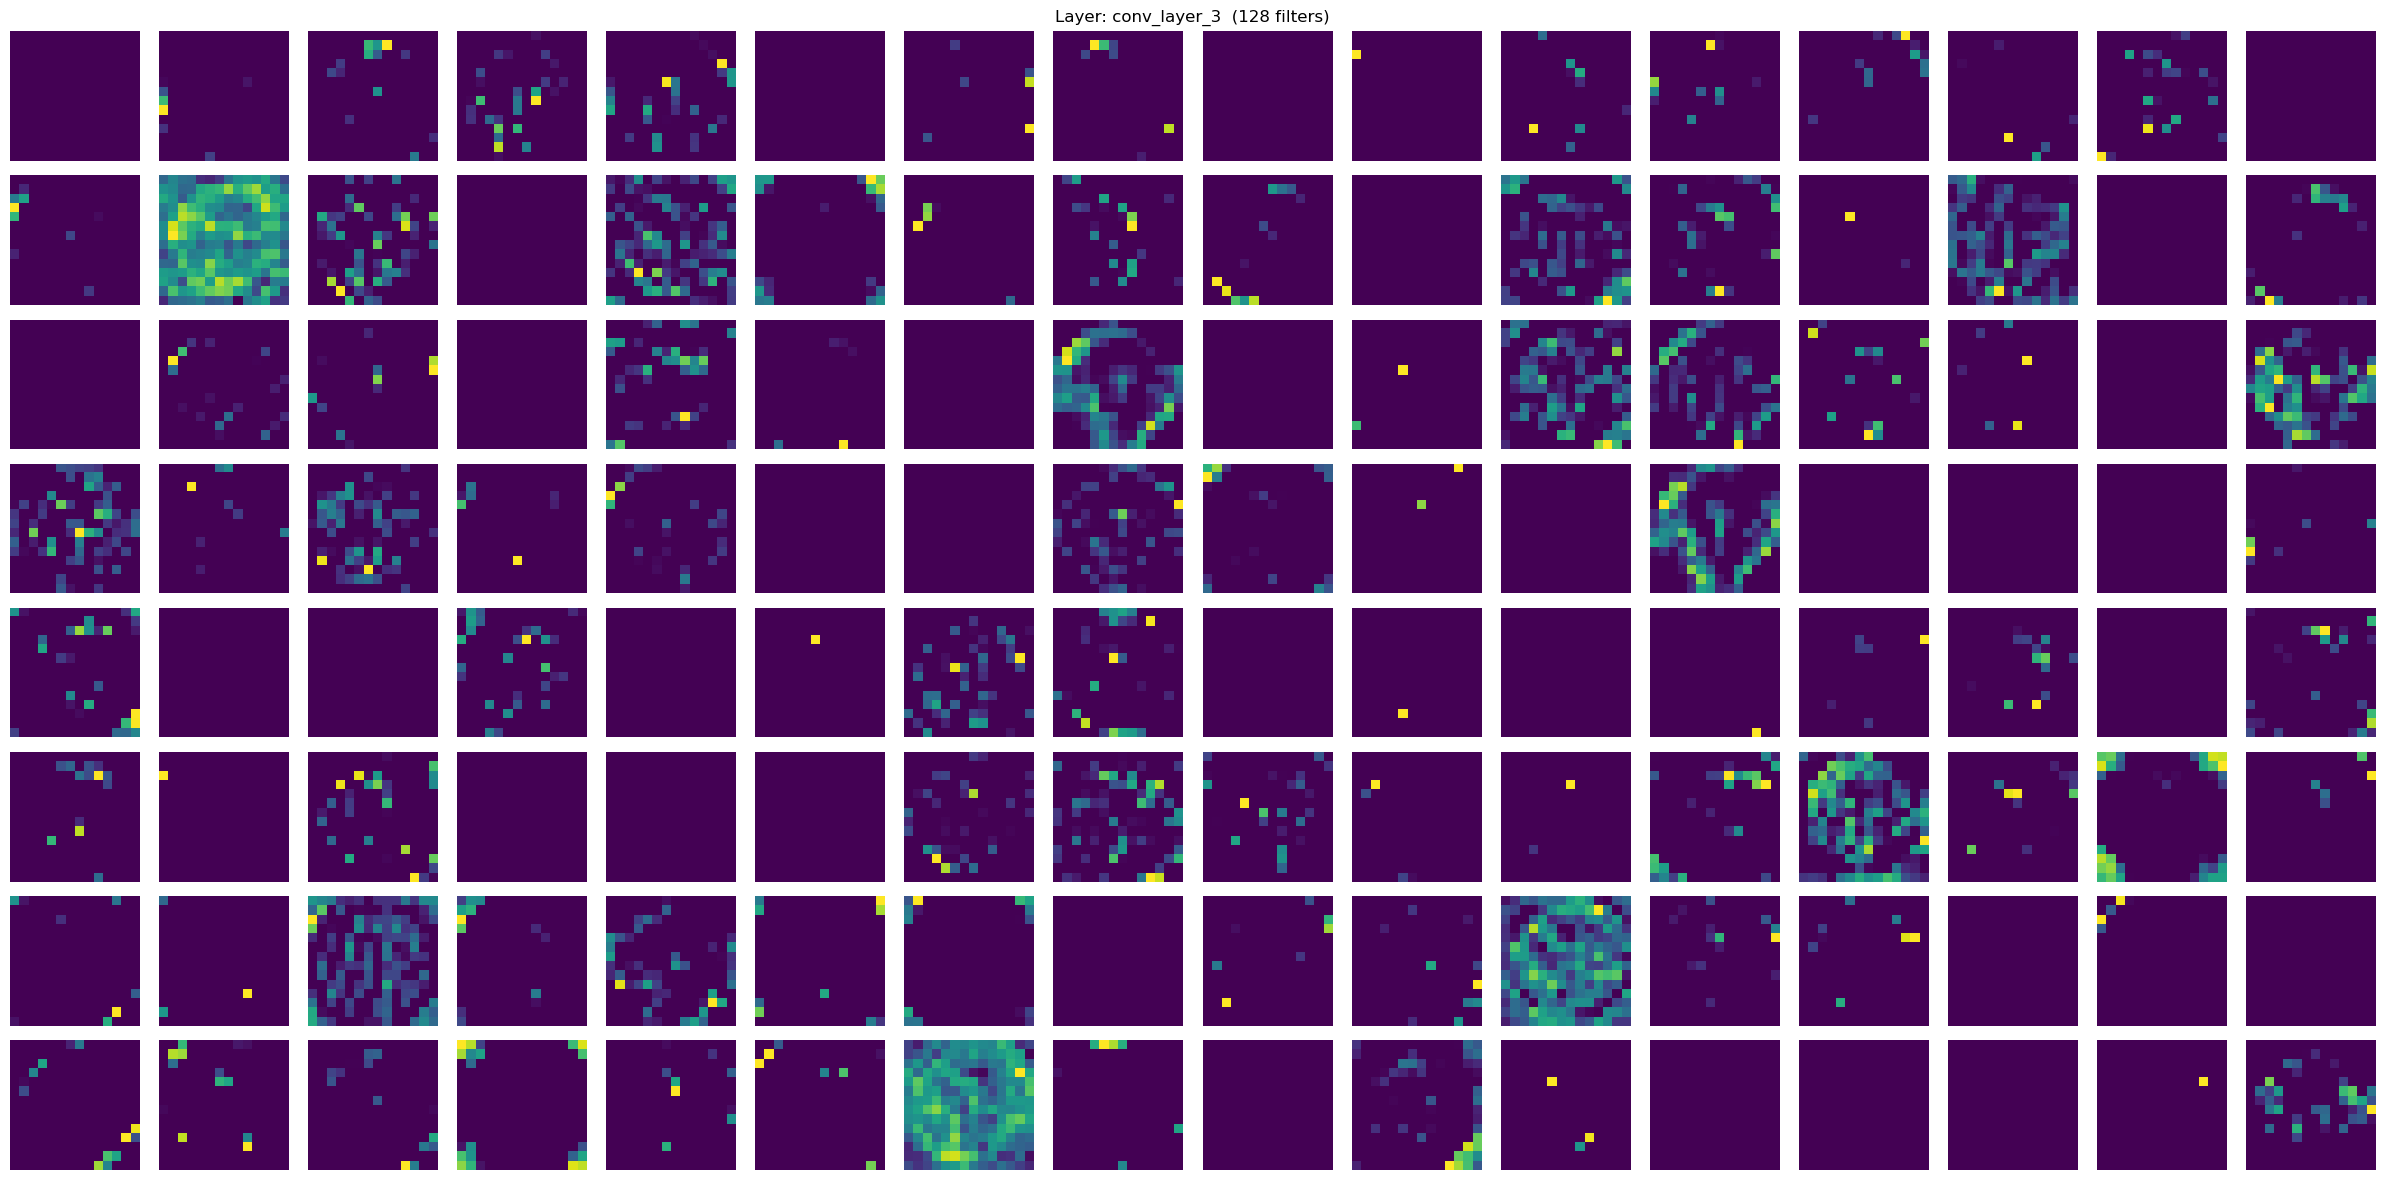

In [114]:
idx = 300
visualize_original_and_maps(models_dict['Exp 3 (Safe Aug + L2)'], X_test[idx], y_true[idx], class_names)